# Human Perception, Cognition & Honest Charts
### Unit 1: Foundations of Visualization, Data Interpretation (UE24CS342AA9)
#### PPT4 Demo — Human Vision, Depth & Motion, Brightness & Contrast, Cognitive Load, Data-Ink Ratio, Proportional Ink

**Dataset:** Video Game Sales (`vgsales.csv`) — 16,598 games with platform, genre,
publisher and regional/global sales figures (1980–2020).

**The scenario:** You are a junior data analyst at **PixelMetrics**, a games-industry
analytics studio. The publishing team is about to pitch investors on "where to publish
next," and your Creative Director has one rule: *"Every chart has to work the way human
eyes and brains actually work — not just the way Excel defaults to drawing it."*

This notebook walks through the full perceptual-science arc from the lecture — from the
biology of the eye through cognitive load and honest chart design — and applies each
principle to the sales dashboard.

## Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.colors import LinearSegmentedColormap

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

df = pd.read_csv("vgsales.csv")
df = df.dropna(subset=["Year", "Publisher"])
print(f"Rows: {len(df):,}  |  Columns: {list(df.columns)}")
df.head()

Rows: 16,291  |  Columns: ['Rank', 'Name', 'Platform', 'Year', 'Genre', 'Publisher', 'NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


## 1. Why Human Vision Matters
Data visualization only works if it aligns with how people naturally perceive
information. Our visual system is optimized to recognize **shapes, colors, motion,
patterns and spatial relationships** almost instantly — this is called **preattentive
processing**. Below, one dot differs from the rest by **color**. Find it, then try
finding the one that differs only by a subtle **shape/rotation** cue.

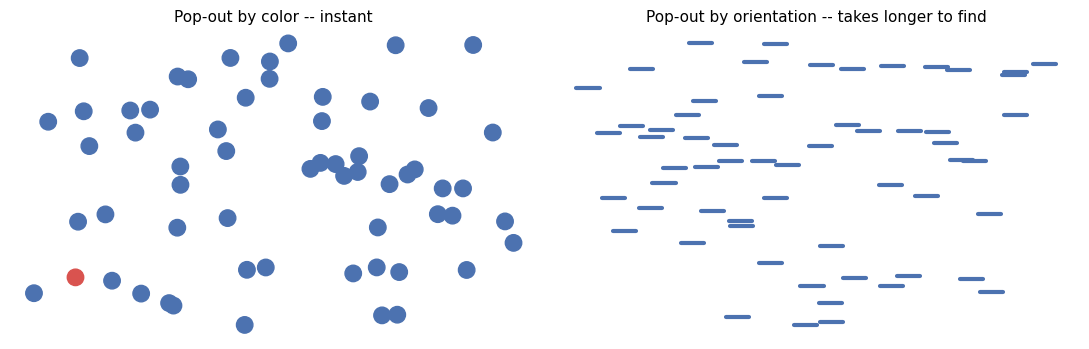

Good visualizations lean on color/size/position pop-out; they don't force the
viewer to hunt for a subtle orientation difference the way a cluttered chart does.


In [ ]:
rng = np.random.default_rng(3)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))

# Panel A: pop-out by color -- effortless, "preattentive"
n = 60
xs, ys = rng.uniform(0, 10, n), rng.uniform(0, 10, n)
colors = ["#4C72B0"] * n
colors[rng.integers(0, n)] = "#D9534F"
axes[0].scatter(xs, ys, s=140, c=colors)
axes[0].set_title("Pop-out by color -- instant", fontsize=11)
axes[0].axis("off")

# Panel B: pop-out by orientation only -- takes visible extra effort to scan
xs2, ys2 = rng.uniform(0, 10, n), rng.uniform(0, 10, n)
angles = np.zeros(n)
odd_idx = rng.integers(0, n)
angles[odd_idx] = 45
for x, y, a in zip(xs2, ys2, angles):
    axes[1].plot([x - 0.25, x + 0.25], [y, y], color="#4C72B0", lw=3,
                 transform=axes[1].transData,
                 solid_capstyle="round",
                 alpha=1, zorder=1,
                 )
axes[1].scatter(xs2, ys2, s=0)  # keep same axis scale
axes[1].set_title("Pop-out by orientation -- takes longer to find", fontsize=11)
axes[1].axis("off")

plt.tight_layout()
plt.show()

print("Good visualizations lean on color/size/position pop-out; they don't force the")
print("viewer to hunt for a subtle orientation difference the way a cluttered chart does.")

## 2. From Eye to Brain: Fovea & Acuity Falloff

Vision has three stages: light hits the retina, the retina's **cones** (color, fine
detail, concentrated in the **fovea**) and **rods** (low-light, motion) convert it to
signals, and the visual cortex builds the final percept. Resolution is sharpest only in
that tiny foveal region — everything in the periphery is naturally blurrier. That's why
readers' eyes constantly jump (*saccade*) to bring each part of a chart onto the fovea.

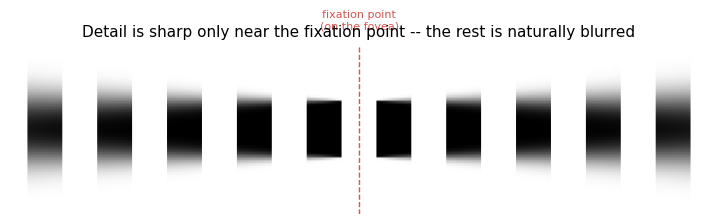

Implication for charts: put the single most important number/label near where
you expect the eye to already be looking -- don't bury it in the periphery.


In [ ]:
from scipy.ndimage import gaussian_filter

# Simulate an eye-chart-like row of digits and blur it more with distance from center (fovea)
fig, ax = plt.subplots(figsize=(9, 2.2))
line = np.ones((60, 600))
for i, cx in enumerate(range(30, 600, 60)):
    line[20:40, cx-15:cx+15] = 0

center = 300
blurred = np.zeros_like(line)
for col in range(line.shape[1]):
    dist = abs(col - center)
    sigma = 0.02 * dist   # more blur = farther from the fovea (center)
    blurred[:, col] = gaussian_filter(line[:, col], sigma=max(sigma, 0.1))

ax.imshow(blurred, cmap="gray", aspect="auto")
ax.axvline(center, color="#D9534F", ls="--", lw=1)
ax.text(center, -6, "fixation point\n(on the fovea)", color="#D9534F", ha="center", fontsize=8)
ax.axis("off")
ax.set_title("Detail is sharp only near the fixation point -- the rest is naturally blurred", fontsize=11)
plt.show()

print("Implication for charts: put the single most important number/label near where")
print("you expect the eye to already be looking -- don't bury it in the periphery.")

## 3. What Is Visual Perception?

Perception is more than seeing: the brain groups raw points into meaningful objects.
Below, every mark is placed **individually and randomly within a shape's silhouette** —
yet the brain instantly reads a coherent shape rather than a cloud of unrelated dots.

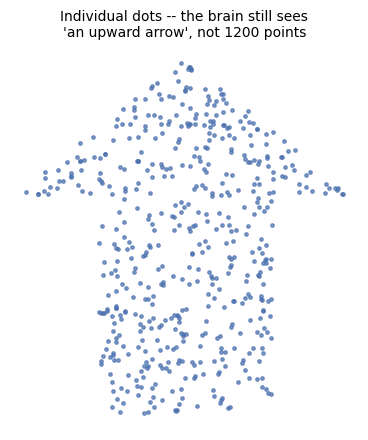

In [ ]:
rng = np.random.default_rng(7)
# Sample points inside a simple arrow-like polygon (rejection sampling) to show a
# shape emerge from unconnected dots
pts = []
for _ in range(6000):
    x, y = rng.uniform(-1, 1), rng.uniform(-1, 1)
    in_shaft = (-0.15 < x < 0.15) and (-0.8 < y < 0.1)
    in_head = (y >= 0.0) and (abs(x) < (0.6 * (0.5 - y)))
    if in_shaft or in_head:
        pts.append((x, y))
pts = np.array(pts)

fig, ax = plt.subplots(figsize=(4.5, 5))
ax.scatter(pts[:, 0], pts[:, 1], s=6, color="#4C72B0", alpha=0.7)
ax.set_title("Individual dots -- the brain still sees\n'an upward arrow', not 1200 points", fontsize=10)
ax.axis("off")
plt.show()

## 4. Depth Perception Cues
The retina's image is 2D, but the brain reconstructs 3D depth using cues like
**texture gradients** (denser/smaller texture = farther away), **relative size**, and
**linear perspective** (parallel lines converge toward the horizon). Below, a simple
tiled "floor" uses all three cues at once to suggest depth with no 3D rendering engine
at all.

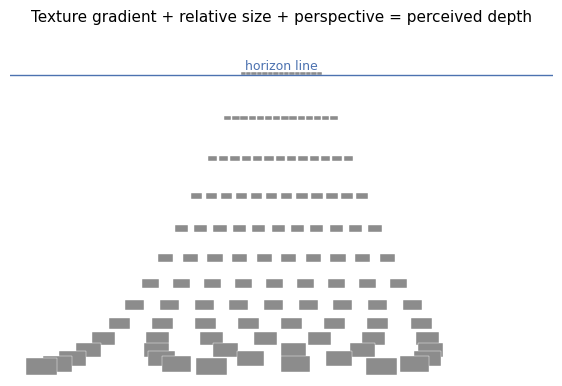

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4.5))

horizon = 1.0
n_rows = 14
for i in range(n_rows):
    frac = i / n_rows                       # 0 = far (near horizon), 1 = near (bottom)
    y = horizon * (1 - frac) ** 2.2          # perspective spacing: rows compress near horizon
    size = 0.02 + 0.10 * frac                # relative size: farther tiles are smaller
    n_tiles = int(3 + 12 * (1 - frac))       # texture density: more, smaller tiles far away
    for j in range(n_tiles):
        x = (j / n_tiles - 0.5) * (0.3 + 1.7 * frac)
        ax.add_patch(patches.Rectangle((x, y), size, size * 0.5,
                                        color="#8c8c8c", ec="white", lw=0.3))

ax.axhline(horizon, color="#4C72B0", lw=1)
ax.text(0, horizon + 0.02, "horizon line", color="#4C72B0", ha="center", fontsize=9)
ax.set_xlim(-1, 1)
ax.set_ylim(0, 1.15)
ax.axis("off")
ax.set_title("Texture gradient + relative size + perspective = perceived depth", fontsize=11)
plt.show()

## 5. Motion & Optical Flow
As we move through a scene, the retinal image shifts continuously — this pattern is
**optical flow**. Nearby objects sweep past quickly; distant objects barely seem to
move. Below, arrow length simulates apparent speed radiating outward from a focus of
expansion (imagine looking straight ahead while walking forward).

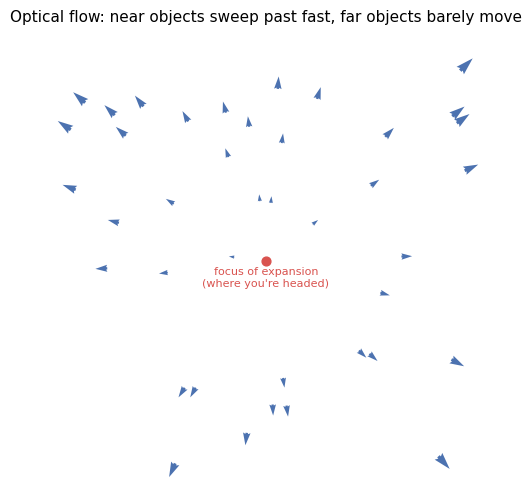

In [ ]:
fig, ax = plt.subplots(figsize=(6, 6))
rng = np.random.default_rng(1)
n = 40
xs = rng.uniform(-8, 8, n)
ys = rng.uniform(-8, 8, n)
dist_from_center = np.sqrt(xs**2 + ys**2)
# Closer objects (small dist) get short arrows in this radial-outflow analogy is reversed:
# objects near the viewer (edges of frame) appear to move fast and far; distant (center) barely move.
scale = 0.15 + 0.05 * dist_from_center
u = xs / dist_from_center * scale
v = ys / dist_from_center * scale

ax.quiver(xs, ys, u, v, color="#4C72B0", angles="xy", scale_units="xy", scale=1)
ax.scatter([0], [0], color="#D9534F", s=40, zorder=3)
ax.text(0, -1, "focus of expansion\n(where you're headed)", color="#D9534F", ha="center", fontsize=8)
ax.set_xlim(-9, 9); ax.set_ylim(-9, 9)
ax.axis("off")
ax.set_title("Optical flow: near objects sweep past fast, far objects barely move", fontsize=11)
plt.show()

## 6. Light and Shading
Three lighting effects reveal different surface information:
- **Lambertian (diffuse) shading** — reveals overall shape/curvature
- **Specular highlights** — reveal glossiness and fine surface detail
- **Cast shadows** — reveal an object's position relative to a surface

Below, the same circle is rendered three ways — flat, with Lambertian shading, and with
shading plus a specular highlight and a cast shadow.

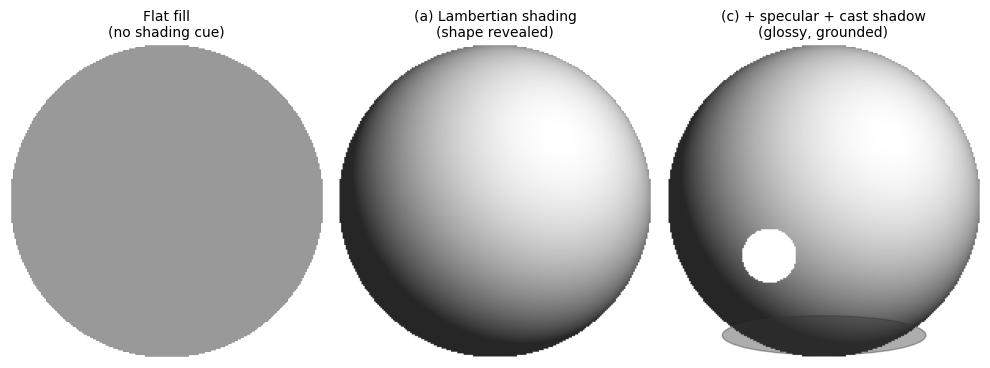

In [ ]:
def sphere_gradient(ax, specular=False, shadow=False):
    size = 200
    yy, xx = np.mgrid[-1:1:complex(size), -1:1:complex(size)]
    r2 = xx**2 + yy**2
    mask = r2 <= 1
    z = np.sqrt(np.clip(1 - r2, 0, 1))
    light_dir = np.array([-0.5, 0.5, 1.0]); light_dir /= np.linalg.norm(light_dir)
    shade = np.clip(xx * -light_dir[0] + yy * -light_dir[1] + z * light_dir[2], 0, 1)
    img = np.where(mask, 0.15 + 0.85 * shade, np.nan)
    if specular:
        hi_mask = ((xx + 0.35)**2 + (yy - 0.35)**2) < 0.03
        img = np.where(hi_mask, 1.0, img)
    ax.imshow(img, cmap="gray", vmin=0, vmax=1)
    if shadow:
        ax.add_patch(patches.Ellipse((100, 185), 130, 25, color="#333333", alpha=0.4))
    ax.axis("off")

fig, axes = plt.subplots(1, 3, figsize=(10, 3.6))
size = 200
yy, xx = np.mgrid[-1:1:complex(size), -1:1:complex(size)]
mask = (xx**2 + yy**2) <= 1
flat = np.where(mask, 0.6, np.nan)
axes[0].imshow(flat, cmap="gray", vmin=0, vmax=1); axes[0].axis("off")
axes[0].set_title("Flat fill\n(no shading cue)", fontsize=10)

sphere_gradient(axes[1])
axes[1].set_title("(a) Lambertian shading\n(shape revealed)", fontsize=10)

sphere_gradient(axes[2], specular=True, shadow=True)
axes[2].set_title("(c) + specular + cast shadow\n(glossy, grounded)", fontsize=10)

plt.tight_layout()
plt.show()

## 7. Display Design Guidelines

Practical guidelines that follow directly from Sections 1–6:

| Guideline | Why |
|---|---|
| Use sufficient contrast | The eye reads edges by contrast, not absolute brightness |
| Avoid tiny text | Acuity has hard limits (Section 2) |
| Avoid relying on color alone | ~1 in 12 men have some color-vision deficiency |
| Reduce visual clutter | Frees attention for the actual data (Section 9 ahead) |
| Place key info near the visual focus | Matches where the eye is already looking (fovea) |

The chart below encodes the same information with **color + direct labels**, so it still
works even for a viewer who can't distinguish the colors.

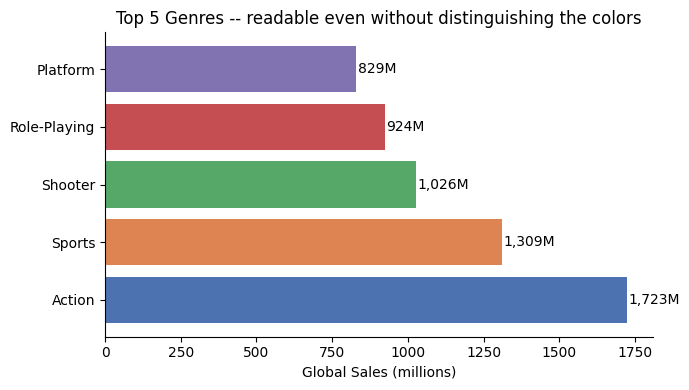

In [ ]:
genre_sales = df.groupby("Genre")["Global_Sales"].sum().sort_values(ascending=False).head(5)

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.barh(genre_sales.index, genre_sales.values,
               color=["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2"])
for bar, val in zip(bars, genre_sales.values):
    ax.text(val + 5, bar.get_y() + bar.get_height()/2, f"{val:,.0f}M", va="center", fontsize=10)
ax.set_xlabel("Global Sales (millions)")
ax.set_title("Top 5 Genres -- readable even without distinguishing the colors")
plt.tight_layout()
plt.show()

## 8. Luminance, Brightness & Lightness

- **Luminance** — the physical, measurable light level
- **Brightness** — the *perceived* intensity of a light source
- **Lightness** — the *perceived* reflectance of a surface

Perception does **not** scale linearly with luminance — it roughly follows a power
law (Stevens' power law). Doubling the physical light does **not** double how bright it
looks.

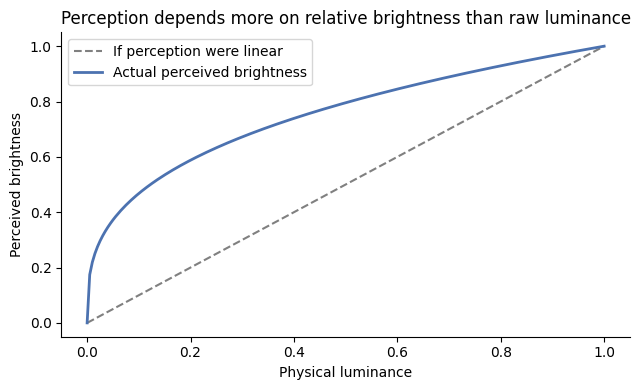

In [ ]:
luminance = np.linspace(0, 1, 200)
perceived_linear = luminance                     # if perception were "honest"
perceived_actual = luminance ** 0.33             # rough power-law approximation

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.plot(luminance, perceived_linear, "--", color="gray", label="If perception were linear")
ax.plot(luminance, perceived_actual, color="#4C72B0", lw=2, label="Actual perceived brightness")
ax.set_xlabel("Physical luminance")
ax.set_ylabel("Perceived brightness")
ax.set_title("Perception depends more on relative brightness than raw luminance")
ax.legend()
plt.tight_layout()
plt.show()

## 9. Brightness Illusions

Because the brain emphasizes local contrast and edges rather than absolute values, the
**same** gray value can look different depending on context. Three classic illusions:

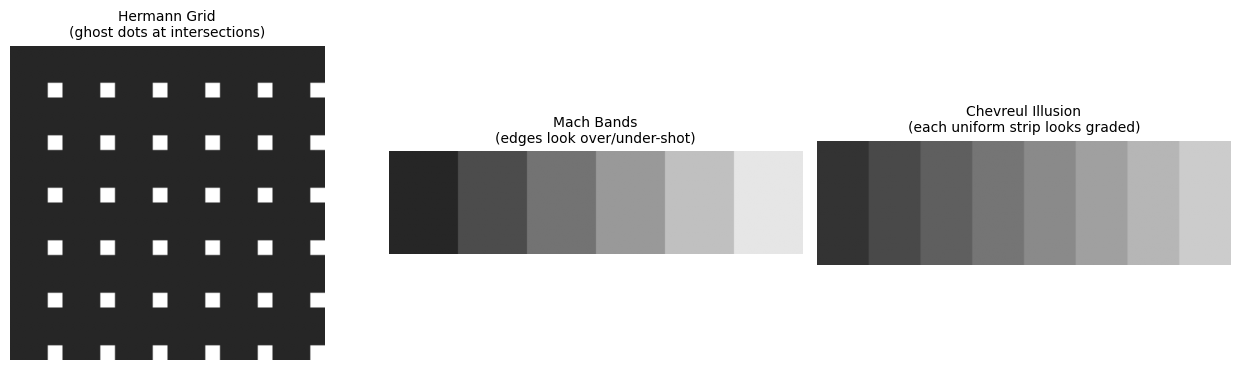

The brain enhances edges and local contrast -- this can distort how gray-scale
encoded data values are read in a chart.


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))

# --- Hermann Grid: faint gray "ghost" dots appear at white intersections ---
grid = np.ones((150, 150))
for i in range(0, 150, 25):
    grid[i:i+18, :] = 0.15
    grid[:, i:i+18] = 0.15
axes[0].imshow(grid, cmap="gray", vmin=0, vmax=1)
axes[0].axis("off")
axes[0].set_title("Hermann Grid\n(ghost dots at intersections)", fontsize=10)

# --- Mach Bands: stepped gray bands look edge-enhanced at each boundary ---
bands = np.tile(np.linspace(0.15, 0.9, 6), (60, 1))
bands = np.repeat(bands, 40, axis=1)
axes[1].imshow(bands, cmap="gray", vmin=0, vmax=1)
axes[1].axis("off")
axes[1].set_title("Mach Bands\n(edges look over/under-shot)", fontsize=10)

# --- Chevreul Illusion: uniform steps look like a smooth ramp with false banding ---
cheveul = np.tile(np.linspace(0.2, 0.8, 8), (60, 1))
cheveul = np.repeat(cheveul, 25, axis=1)
axes[2].imshow(cheveul, cmap="gray", vmin=0, vmax=1)
axes[2].axis("off")
axes[2].set_title("Chevreul Illusion\n(each uniform strip looks graded)", fontsize=10)

plt.tight_layout()
plt.show()

print("The brain enhances edges and local contrast -- this can distort how gray-scale")
print("encoded data values are read in a chart.")

## 10. Gray Scales & Lightness Constancy

Two problems with gray-scale encodings for quantitative data: **(a)** equal numeric
steps are not perceived as equally-spaced, and **(b)** the brain applies **lightness
constancy** — adjusting for surrounding context so the same physical gray can look
completely different depending on its "lighting.\"

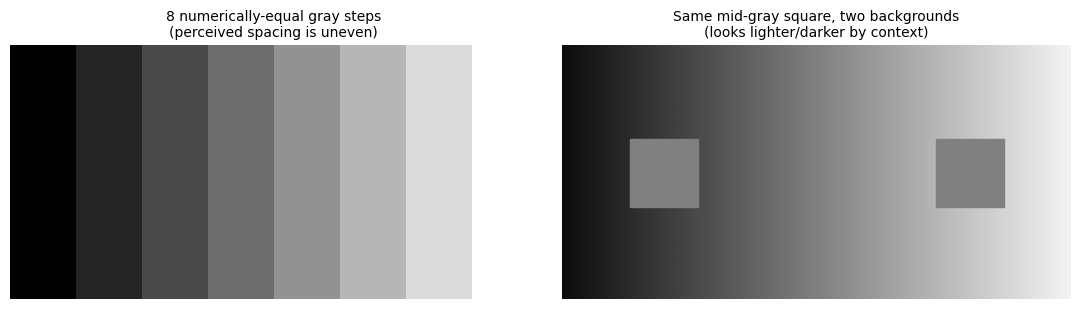

Guideline from the lecture: avoid grayscale for many distinct numerical values --
use a deliberately designed color scale instead.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))

# (a) Equal numeric steps -- do they look equally spaced?
steps = np.linspace(0, 1, 8).reshape(1, -1)
axes[0].imshow(np.repeat(steps, 40, axis=0), cmap="gray", vmin=0, vmax=1, aspect="auto")
axes[0].set_title("8 numerically-equal gray steps\n(perceived spacing is uneven)", fontsize=10)
axes[0].axis("off")

# (b) Lightness constancy: identical gray patch on two different gradient backgrounds
bg = np.tile(np.linspace(0.05, 0.95, 300), (150, 1))
axes[1].imshow(bg, cmap="gray", vmin=0, vmax=1)
axes[1].add_patch(patches.Rectangle((40, 55), 40, 40, color="#808080"))
axes[1].add_patch(patches.Rectangle((220, 55), 40, 40, color="#808080"))
axes[1].set_title("Same mid-gray square, two backgrounds\n(looks lighter/darker by context)", fontsize=10)
axes[1].axis("off")

plt.tight_layout()
plt.show()

print("Guideline from the lecture: avoid grayscale for many distinct numerical values --")
print("use a deliberately designed color scale instead.")

## 11. Contrast & the Minimum Ratio Guideline  

Research recommends a **minimum 3:1 luminance contrast ratio** for fine details like
text. Below, we compute a simple relative-luminance contrast ratio for a few
text/background color pairs a dashboard might use, and check which ones actually clear
that bar.

In [ ]:
def relative_luminance(hex_color):
    hex_color = hex_color.lstrip("#")
    r, g, b = (int(hex_color[i:i+2], 16) / 255 for i in (0, 2, 4))
    def lin(c):
        return c / 12.92 if c <= 0.03928 else ((c + 0.055) / 1.055) ** 2.4
    r, g, b = lin(r), lin(g), lin(b)
    return 0.2126 * r + 0.7152 * g + 0.0722 * b

def contrast_ratio(hex1, hex2):
    l1, l2 = relative_luminance(hex1), relative_luminance(hex2)
    lighter, darker = max(l1, l2), min(l1, l2)
    return (lighter + 0.05) / (darker + 0.05)

pairs = [
    ("Dark text on white",     "#333333", "#FFFFFF"),
    ("Mid-gray text on white", "#AAAAAA", "#FFFFFF"),
    ("Light gray on cream",    "#CCCCCC", "#F5F5DC"),
    ("Blue on white",          "#4C72B0", "#FFFFFF"),
]

print(f"{'Pair':<28}{'Contrast Ratio':<16}{'Passes 3:1 min?'}")
for label, fg, bg in pairs:
    ratio = contrast_ratio(fg, bg)
    print(f"{label:<28}{ratio:<16.2f}{'YES' if ratio >= 3 else 'NO'}")

Pair                        Contrast Ratio  Passes 3:1 min?
Dark text on white          12.63           YES
Mid-gray text on white      2.32            NO
Light gray on cream         1.45            NO
Blue on white               4.84            YES


## 12. Cognitive Load & the Data-Ink Ratio  
**Cognitive load** is the mental effort a viewer spends decoding a chart before they can
even get to the message. Edward Tufte's **data-ink ratio** says: maximize the ink that
represents data, minimize everything else ("chart junk" — heavy borders, gridlines, 3D
effects, shadows, decoration).

Below: the *same* question — "which platform generation dominates global sales?" —
answered twice, using the top platforms by total sales.

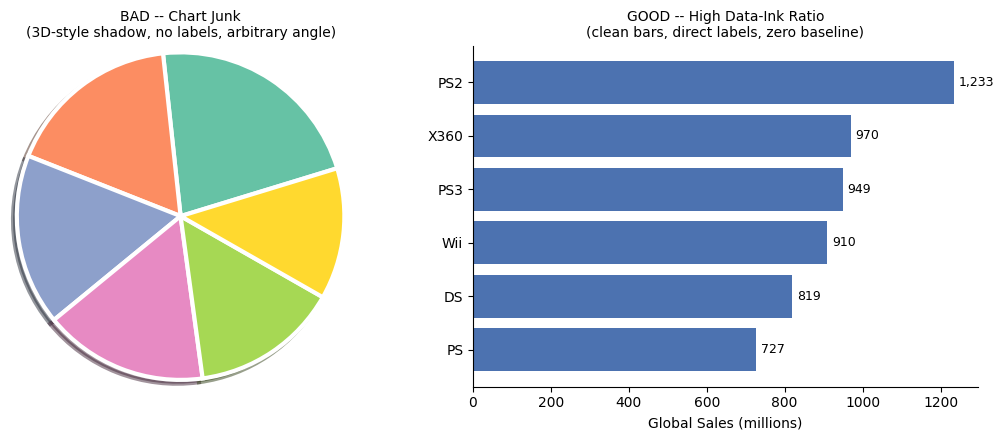

The bad chart forces the viewer to match colors to a legend and estimate wedge angles.
The good chart lets them read exact totals directly off the axis -- almost zero decoding effort.


In [ ]:
top_platforms = df.groupby("Platform")["Global_Sales"].sum().sort_values(ascending=False).head(6)

fig = plt.figure(figsize=(11, 4.5))

# ---- BAD: chart junk ----
ax1 = fig.add_subplot(1, 2, 1)
ax1.pie(
    top_platforms.values,
    colors=["#66c2a5", "#fc8d62", "#8da0cb", "#e78ac3", "#a6d854", "#ffd92f"],
    shadow=True, startangle=17, radius=1.2,
    wedgeprops={"edgecolor": "white", "linewidth": 3},
)
ax1.set_title("BAD -- Chart Junk\n(3D-style shadow, no labels, arbitrary angle)", fontsize=10)

# ---- GOOD: high data-ink ratio ----
ax2 = fig.add_subplot(1, 2, 2)
order = top_platforms.sort_values()
bars = ax2.barh(order.index, order.values, color="#4C72B0")
ax2.set_title("GOOD -- High Data-Ink Ratio\n(clean bars, direct labels, zero baseline)", fontsize=10)
ax2.set_xlabel("Global Sales (millions)")
for spine in ["top", "right"]:
    ax2.spines[spine].set_visible(False)
for bar, val in zip(bars, order.values):
    ax2.text(val + max(order.values) * 0.01, bar.get_y() + bar.get_height() / 2,
              f"{val:,.0f}", va="center", fontsize=9)

plt.tight_layout()
plt.show()

print("The bad chart forces the viewer to match colors to a legend and estimate wedge angles.")
print("The good chart lets them read exact totals directly off the axis -- almost zero decoding effort.")

### Signal vs. Noise  

| Signal (keep) | Noise (remove) |
|---|---|
| Data values (bar lengths, point positions) | Decorative icons, clip-art |
| Trends / comparisons | Unnecessary colors, gradients |
| Direct value labels | Drop shadows, 3D bevels |
| Axis needed for interpretation | Redundant legends when direct labels exist |

💡 *If an element doesn't improve understanding, remove it.*

## 13. Principle of Proportional Ink  

The **size** of a visual element should be proportional to the value it represents.
Truncating a bar's baseline away from zero exaggerates differences and violates this
principle — a classic way dashboards mislead investors without anyone intending to lie.

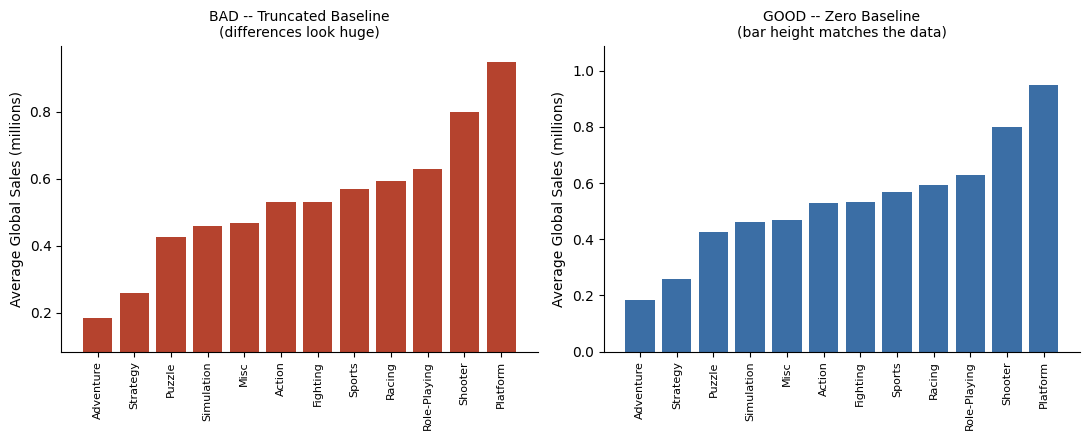

The real difference between the highest- and lowest-selling genre is about 415%.
The truncated chart on the left visually implies a far larger gap than that.


In [ ]:
genre_avg = df.groupby("Genre")["Global_Sales"].mean().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# BAD: truncated baseline exaggerates the differences
axes[0].bar(genre_avg.index, genre_avg.values, color="#b5432e")
axes[0].set_ylim(genre_avg.min() - 0.1, genre_avg.max() + 0.05)   # baseline NOT at zero
axes[0].set_title("BAD -- Truncated Baseline\n(differences look huge)", fontsize=10)
axes[0].set_ylabel("Average Global Sales (millions)")
axes[0].tick_params(axis="x", rotation=90, labelsize=8)

# GOOD: zero baseline, honest proportions
axes[1].bar(genre_avg.index, genre_avg.values, color="#3b6ea5")
axes[1].set_ylim(0, genre_avg.max() * 1.15)                       # baseline at zero
axes[1].set_title("GOOD -- Zero Baseline\n(bar height matches the data)", fontsize=10)
axes[1].set_ylabel("Average Global Sales (millions)")
axes[1].tick_params(axis="x", rotation=90, labelsize=8)

plt.tight_layout()
plt.show()

pct_diff = (genre_avg.max() - genre_avg.min()) / genre_avg.min() * 100
print(f"The real difference between the highest- and lowest-selling genre is about {pct_diff:.0f}%.")
print("The truncated chart on the left visually implies a far larger gap than that.")

### Log Scales: Bars vs. Points  

`Global_Sales` is heavily right-skewed at the publisher level (a handful of publishers
dominate, most sell far less), so a **log axis** is appropriate. But on a log axis,
**bar length** is no longer proportional to the underlying value — only **position** is.
Bars distort the comparison; points do not.

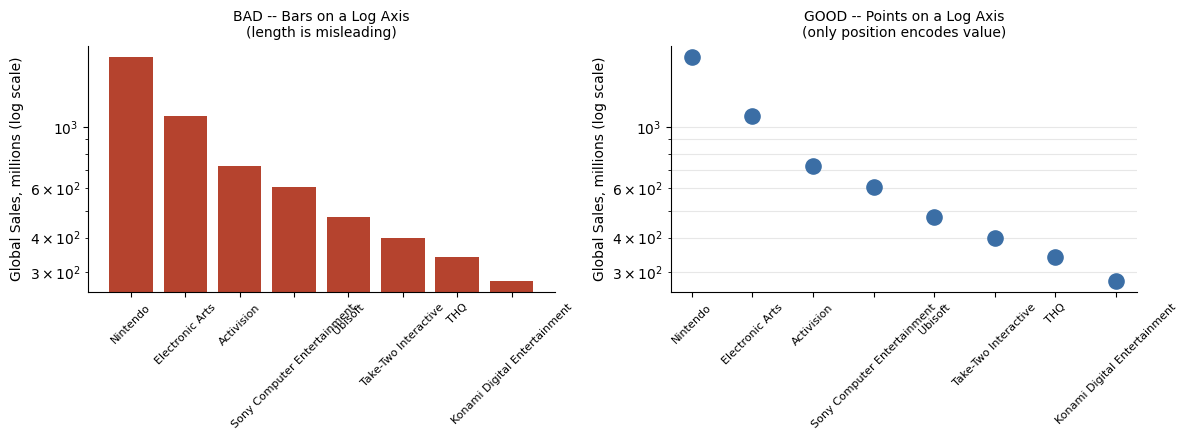

In [ ]:
top_publishers = df.groupby("Publisher")["Global_Sales"].sum().sort_values(ascending=False).head(8)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# BAD: bar chart on a log axis -- length no longer means what it looks like it means
axes[0].bar(top_publishers.index, top_publishers.values, color="#b5432e")
axes[0].set_yscale("log")
axes[0].set_title("BAD -- Bars on a Log Axis\n(length is misleading)", fontsize=10)
axes[0].set_ylabel("Global Sales, millions (log scale)")
axes[0].tick_params(axis="x", rotation=45, labelsize=8)

# GOOD: point plot on a log axis -- only position encodes the value
axes[1].scatter(top_publishers.index, top_publishers.values, s=120, color="#3b6ea5", zorder=3)
axes[1].set_yscale("log")
axes[1].set_title("GOOD -- Points on a Log Axis\n(only position encodes value)", fontsize=10)
axes[1].set_ylabel("Global Sales, millions (log scale)")
axes[1].tick_params(axis="x", rotation=45, labelsize=8)
axes[1].grid(axis="y", which="both", alpha=0.3)

plt.tight_layout()
plt.show()

Log axis:
Equal steps = equal multiples, not equal amounts.
So instead of going 0, 10, 20, 30..., 
a log axis might go 1, 10, 100, 1000, 10,000 — each step is "×10" the previous one, not "+10."
Bar length only tells the truth on a normal (linear) scale.
If you must use a log scale, use dots/points instead of bars — otherwise the chart looks accurate but is secretly misleading.


## Key Takeaways

1. **Vision starts in the eye but ends in the brain** — the fovea is sharp, the
   periphery is naturally blurred, and perception groups raw signals into objects.
2. **Depth, motion and shading cues** (texture gradients, optical flow, Lambertian
   shading, cast shadows) let 2D charts and maps read as spatially meaningful.
3. **Design for the fovea, not the ideal viewer** — labels, lines and markers need to
   survive real acuity and contrast limits (aim for at least a 3:1 contrast ratio).
4. **Brightness is relative, not absolute** — illusions like Hermann Grid, Mach Bands
   and the Chevreul Illusion show why gray-scale alone is risky for quantitative data.
5. **Every extra pixel costs attention** — maximize the data-ink ratio; cut chart junk.
6. **Visual size must match the data** — zero baselines for bars/areas; points (not
   bars) on log scales.

> *A visualization should make insight easier to reach, not harder to decode.*